In [1]:
from sklearn.datasets import load_iris

In [2]:
import numpy as np

In [3]:
iris = load_iris(as_frame=True)

In [4]:
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [5]:
iris.data.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [6]:
iris.target.head(3)

0    0
1    0
2    0
Name: target, dtype: int64

In [7]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

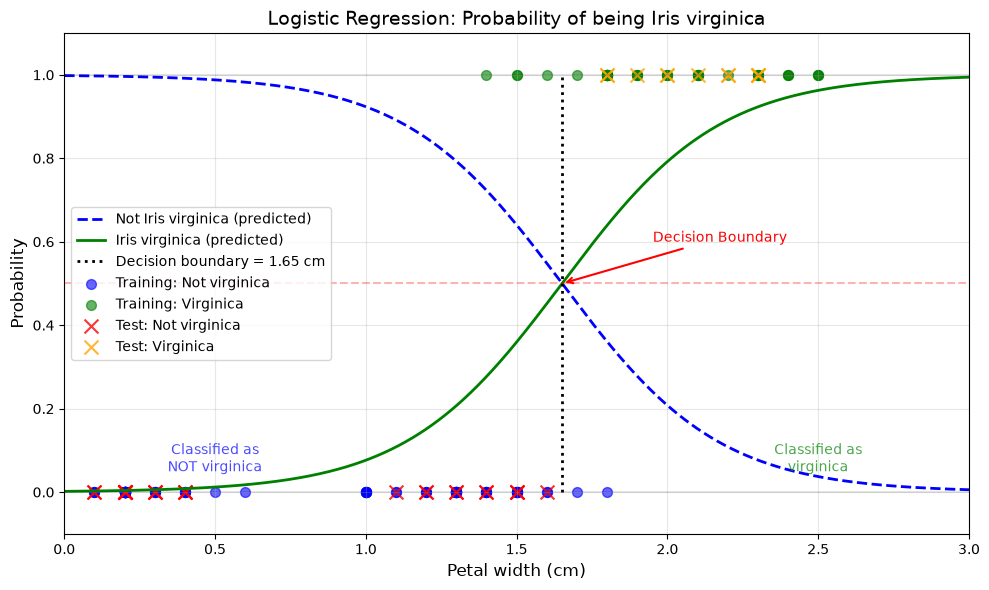

Decision boundary (petal width): 1.652 cm

Training set:
  - Non-virginica samples: 74
  - Virginica samples: 38

Test set:
  - Non-virginica samples: 26
  - Virginica samples: 12

Model Accuracy:
  - Training set: 0.946
  - Test set: 1.000


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Load data
iris = load_iris()

# CORRECTED: Use integer index instead of column name
X = iris.data[:, [3]]  # Column 3 = petal width (cm)
# Alternative: X = iris.data[:, 3].reshape(-1, 1)

# Convert to binary classification: is it virginica?
y = iris.target_names[iris.target] == 'virginica'

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Train logistic regression on TRAINING data only
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

# Create smooth X values for plotting
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)
y_proba = log_reg.predict_proba(X_new)

# Find decision boundary (where probability = 0.5)
decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0]

# Create the plot
plt.figure(figsize=(10, 6))

# Plot probability curves
plt.plot(X_new, y_proba[:, 0], "b--", linewidth=2, label="Not Iris virginica (predicted)")
plt.plot(X_new, y_proba[:, 1], "g-", linewidth=2, label="Iris virginica (predicted)")

# Plot decision boundary line
plt.plot([decision_boundary, decision_boundary], [0, 1], "k:", linewidth=2, 
         label=f"Decision boundary = {decision_boundary:.2f} cm")

# Plot TRAINING data points (circles)
plt.scatter(X_train[y_train == 0], np.zeros(sum(y_train == 0)), 
            color='blue', alpha=0.6, s=50, marker='o',
            label='Training: Not virginica')
plt.scatter(X_train[y_train == 1], np.ones(sum(y_train == 1)), 
            color='green', alpha=0.6, s=50, marker='o',
            label='Training: Virginica')

# Plot TEST data points (X markers)
plt.scatter(X_test[y_test == 0], np.zeros(sum(y_test == 0)), 
            color='red', alpha=0.8, s=100, marker='x',
            label='Test: Not virginica')
plt.scatter(X_test[y_test == 1], np.ones(sum(y_test == 1)), 
            color='orange', alpha=0.8, s=100, marker='x',
            label='Test: Virginica')

# Beautify the plot
plt.xlabel("Petal width (cm)", fontsize=12)
plt.ylabel("Probability", fontsize=12)
plt.title("Logistic Regression: Probability of being Iris virginica", fontsize=14)
plt.legend(loc='center left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.ylim(-0.1, 1.1)
plt.xlim(0, 3)

# Add horizontal reference lines
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.3, label='Threshold = 0.5')
plt.axhline(y=0, color='black', alpha=0.1)
plt.axhline(y=1, color='black', alpha=0.1)

# Add vertical line at decision boundary with arrow annotations
plt.annotate('Decision Boundary', 
             xy=(decision_boundary, 0.5), 
             xytext=(decision_boundary + 0.3, 0.6),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=10, color='red')

# Add classification regions
plt.text(0.5, 0.05, 'Classified as\nNOT virginica', 
         ha='center', fontsize=10, color='blue', alpha=0.7)
plt.text(2.5, 0.05, 'Classified as\nvirginica', 
         ha='center', fontsize=10, color='green', alpha=0.7)

plt.tight_layout()
plt.show()

# Print additional info
print(f"Decision boundary (petal width): {decision_boundary:.3f} cm")
print(f"\nTraining set:")
print(f"  - Non-virginica samples: {sum(y_train == 0)}")
print(f"  - Virginica samples: {sum(y_train == 1)}")
print(f"\nTest set:")
print(f"  - Non-virginica samples: {sum(y_test == 0)}")
print(f"  - Virginica samples: {sum(y_test == 1)}")

# Evaluate model performance on test set
train_accuracy = log_reg.score(X_train, y_train)
test_accuracy = log_reg.score(X_test, y_test)
print(f"\nModel Accuracy:")
print(f"  - Training set: {train_accuracy:.3f}")
print(f"  - Test set: {test_accuracy:.3f}")

In [10]:
 log_reg.predict([[1.7], [1.5]])

array([ True, False])

In [11]:
iris = load_iris(as_frame=True)


In [12]:
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

softmax_reg = LogisticRegression(C=30, random_state=42)
softmax_reg.fit(X_train, y_train)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",30
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver

In [15]:
softmax_reg.predict([[5, 2]])

array([2])

In [16]:
softmax_reg.predict_proba([[5, 2]]).round(2)

array([[0.  , 0.04, 0.96]])

### Q. Implement batch gradient descent with early stopping for softmax regression without using Scikit-Learn, only NumPy. Use it on a classification task such as the iris dataset.

In [22]:
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris["target"].values

In [23]:
X_with_bias = np.c_[np.ones(len(X)), X]

In [24]:
test_ratio = 0.2
validation_ratio = 0.2
total_size = len(X_with_bias)

test_size = int(total_size * test_ratio)
validation_size = int(total_size * validation_ratio)
train_size = total_size - test_size - validation_size

rng = np.random.default_rng(seed=42)
rnd_indices = rng.permutation(total_size)

X_train = X_with_bias[rnd_indices[:train_size]]
y_train = y[rnd_indices[:train_size]]
X_valid = X_with_bias[rnd_indices[train_size:-test_size]]
y_valid = y[rnd_indices[train_size:-test_size]]
X_test = X_with_bias[rnd_indices[-test_size:]]
y_test = y[rnd_indices[-test_size:]]

In [25]:
def to_one_hot(y):
    return np.diag(np.ones(y.max() + 1))[y]

In [26]:
y_train[:10]

array([1, 1, 2, 0, 2, 2, 1, 2, 2, 0])

In [27]:
to_one_hot(y_train[:10])

array([[0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.]])

In [28]:
Y_train_one_hot = to_one_hot(y_train)
Y_valid_one_hot = to_one_hot(y_valid)
Y_test_one_hot = to_one_hot(y_test)

In [29]:
mean = X_train[:, 1:].mean(axis=0)
std = X_train[:, 1:].std(axis=0)
X_train[:, 1:] = (X_train[:, 1:] - mean) / std
X_valid[:, 1:] = (X_valid[:, 1:] - mean) / std
X_test[:, 1:] = (X_test[:, 1:] - mean) / std

In [30]:
def softmax(logits):
    exps = np.exp(logits)
    exp_sums = exps.sum(axis=1, keepdims=True)
    return exps / exp_sums